# DS 4320 Project 1 Pipeline: Predicting Credit Card Default Risk

This notebook presents the end-to-end pipeline for the credit default prediction project. It loads relational tables into DuckDB, uses SQL to create a modeling table, performs exploratory analysis, trains machine learning models, and evaluates model performance.

## Research Question
Can demographic information, credit limit, billing history, and repayment behavior from the previous six months predict whether a client will default next month?

## Import Libraries

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    ConfusionMatrixDisplay
)

## Connect to DuckDB

In [4]:
con = duckdb.connect("credit_default.duckdb")
with open("../sql/load_tables.sql", "r") as f:
    load_sql = f.read()

con.execute(load_sql)

## Data Preparation and Relational Restructuring

The original dataset was stored as a wide table with repeated monthly variables. A separate Python script (`scr/create_tables.py`) was used to restructure the raw data into four relational tables:

- `clients`
- `credit_accounts`
- `repayment_history`
- `monthly_financials`

This notebook begins from those processed tables and loads them into DuckDB for SQL-based feature engineering and modeling.

In [5]:
con.sql("SELECT * FROM clients LIMIT 5").df()

,client_id,sex,education,marriage,age
0,1,2,2,1,24
1,2,2,2,2,26
2,3,2,2,2,34
3,4,2,2,1,37
4,5,1,2,1,57


In [6]:
con.sql("SELECT * FROM credit_accounts LIMIT 5").df()

,client_id,limit_bal,default_next_month
0,1,20000,1
1,2,120000,1
2,3,90000,0
3,4,50000,0
4,5,50000,0


In [7]:
con.sql("SELECT * FROM monthly_financials LIMIT 5").df()

,client_id,month_index,bill_amount,pay_amount
0,1,1,3913,0
1,1,2,3102,689
2,1,3,689,0
3,1,4,0,0
4,1,5,0,0


In [8]:
con.sql("SELECT * FROM repayment_history LIMIT 5").df()

,client_id,month_index,repayment_status
0,1,1,2
1,1,2,2
2,1,3,-1
3,1,4,-1
4,1,5,-2


In [34]:
clients = pd.read_csv("/workspaces/Datadesign_Project1/data_processed/clients.csv")
credit_accounts = pd.read_csv("/workspaces/Datadesign_Project1/data_processed/credit_accounts.csv")
repayment_history = pd.read_csv("/workspaces/Datadesign_Project1/data_processed/repayment_history.csv")
monthly_financials = pd.read_csv("/workspaces/Datadesign_Project1/data_processed/monthly_financials.csv")

clients["age"].agg(["mean", "std", "min", "max"])

mean    35.485500
std      9.217904
min     21.000000
max     79.000000
Name: age, dtype: float64

In [35]:
credit_accounts["limit_bal"].agg(["mean", "std", "min", "max"])

mean     167484.322667
std      129747.661567
min       10000.000000
max     1000000.000000
Name: limit_bal, dtype: float64

In [36]:
repayment_history["repayment_status"].agg(["mean", "std", "min", "max"])

mean   -0.182439
std     1.165641
min    -2.000000
max     8.000000
Name: repayment_status, dtype: float64

In [37]:
monthly_financials["bill_amount"].agg(["mean", "std", "min", "max"])

mean    4.497695e+04
std     6.683443e+04
min    -3.396030e+05
max     1.664089e+06
Name: bill_amount, dtype: float64

## Making the Main Modeling Table

Right now we have 4 seperate tables, which are record the clients information, the account status, the repayment history and the monthly_financials, but we do not need all the information for sovling our question, also we need to summarize some features to one features, like for features: bill_amt1...bill_amt6, pay_amt1...pay_amt6. We only need the average. So I am doing the feature queries here, to join the tables by primary keys, and summarize some features, and drops some features to make a new final table.

In [9]:
con.execute(open("../sql/feature_queries.sql").read())

In [10]:
con.sql("SELECT * FROM modeling_table LIMIT 5").df()

,client_id,sex,education,marriage,age,limit_bal,default_next_month,max_repayment_status,avg_repayment_status,delayed_month_count,avg_bill_amount,avg_pay_amount,avg_payment_bill_ratio
0,1,2,2,1,24,20000,1,2,-0.333333,2.0,1284.000000,114.833333,0.089434
1,2,2,2,2,26,120000,1,2,0.500000,2.0,2846.166667,833.333333,0.292791
2,3,2,2,2,34,90000,0,0,0.000000,0.0,16942.166667,1836.333333,0.108388
3,4,2,2,1,37,50000,0,0,0.000000,0.0,38555.666667,1398.000000,0.036259
4,5,1,2,1,57,50000,0,0,-0.333333,0.0,18223.166667,9841.500000,0.540054


The modeling table aggregates the monthly repayment and financial history into client-level features so that each row corresponds to one client.

## Loading the Table to Pandas and Check the Data Quality

In [11]:
Model_df = con.sql("SELECT * FROM modeling_table").df()
Model_df.head()

,client_id,sex,education,marriage,age,limit_bal,default_next_month,max_repayment_status,avg_repayment_status,delayed_month_count,avg_bill_amount,avg_pay_amount,avg_payment_bill_ratio
0,1,2,2,1,24,20000,1,2,-0.333333,2.0,1284.000000,114.833333,0.089434
1,2,2,2,2,26,120000,1,2,0.500000,2.0,2846.166667,833.333333,0.292791
2,3,2,2,2,34,90000,0,0,0.000000,0.0,16942.166667,1836.333333,0.108388
3,4,2,2,1,37,50000,0,0,0.000000,0.0,38555.666667,1398.000000,0.036259
4,5,1,2,1,57,50000,0,0,-0.333333,0.0,18223.166667,9841.500000,0.540054


In [12]:
Model_df.isna().sum()

client_id                   0
sex                         0
education                   0
marriage                    0
age                         0
limit_bal                   0
default_next_month          0
max_repayment_status        0
avg_repayment_status        0
delayed_month_count         0
avg_bill_amount             0
avg_pay_amount              0
avg_payment_bill_ratio    870
dtype: int64

The only feature contain missing value is "avg_payment_bill_ratio", which is a feature i made for the modeling table. If one client do not need to pay any for the bill, the ratio will be zero. So this kind of missing value will not effect model a lot.

In [13]:
Model_df["default_next_month"].value_counts()

default_next_month
0    23364
1     6636
Name: count, dtype: int64

In [14]:
Model_df["default_next_month"].value_counts(normalize=True)

default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

## Describative Analysis

In [15]:
Model_df["default_next_month"].mean()

np.float64(0.2212)

In [16]:
Model_df.groupby("delayed_month_count")["default_next_month"].mean()

delayed_month_count
0.0    0.117104
1.0    0.298238
2.0    0.387572
3.0    0.508666
4.0    0.573081
5.0    0.573826
6.0    0.703207
Name: default_next_month, dtype: float64

In [17]:
Model_df.groupby("max_repayment_status")["default_next_month"].mean()

max_repayment_status
-2    0.134661
-1    0.147116
 0    0.108306
 1    0.249852
 2    0.435509
 3    0.622307
 4    0.642202
 5    0.507246
 6    0.560000
 7    0.835821
 8    0.560000
Name: default_next_month, dtype: float64

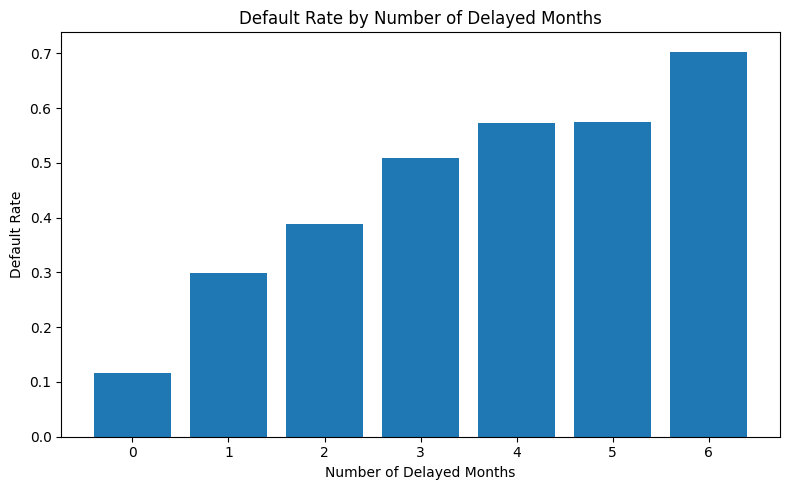

In [18]:
delay_default = (
    Model_df.groupby("delayed_month_count")["default_next_month"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(delay_default["delayed_month_count"], delay_default["default_next_month"])
plt.xlabel("Number of Delayed Months")
plt.ylabel("Default Rate")
plt.title("Default Rate by Number of Delayed Months")
plt.tight_layout()
plt.savefig("figures", dpi=300)
plt.show()

Clients with more delayed months tend to have a higher probability to default next month.

## Train Test Split

In [19]:
X = Model_df.drop(columns=["client_id", "default_next_month"])
y = Model_df["default_next_month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train the Model

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [21]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

## Model Evaulation

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

results_df

,Metric,Value
0,Accuracy,0.747167
1,Precision,0.448649
2,Recall,0.625471
3,F1 Score,0.522506
4,ROC AUC,0.766402


The random forest model achieved an accuracy of 0.747, a precision of 0.449, a recall of 0.625, an F1 score of 0.523, and a ROC AUC of 0.766. These results suggest that the model has moderate predictive performance overall and is meaningfully better than random classification.

Among these metrics, recall is especially important in this project because the goal is to identify clients at risk of default. A recall of 0.625 means that the model correctly identifies about 62.5% of actual default cases. This indicates that the model is reasonably effective at detecting higher-risk clients, although it still misses a portion of them.

The ROC AUC of 0.766 shows that the model has a good overall ability to distinguish between default and non-default clients. While the precision of 0.449 indicates that the model also produces false positives, the results are still useful for risk screening, where identifying more potentially risky clients may be preferable to missing too many true defaults.


In [23]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4673
           1       0.45      0.63      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.68      6000
weighted avg       0.78      0.75      0.76      6000

[[3653 1020]
 [ 497  830]]


## Confusion Matrix

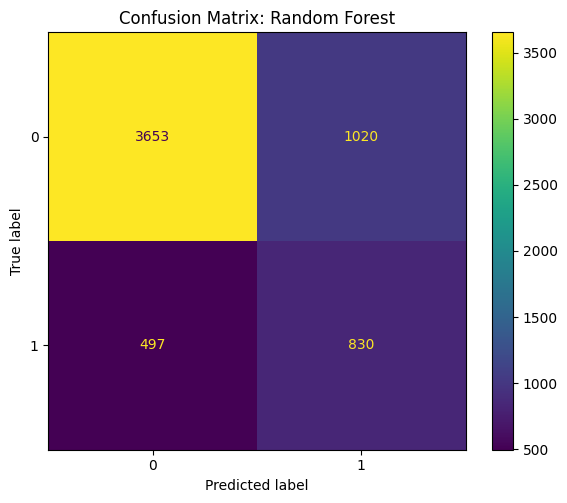

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("Confusion Matrix: Random Forest")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_random_forest.png", dpi=300)
plt.show()

## ROC Curve

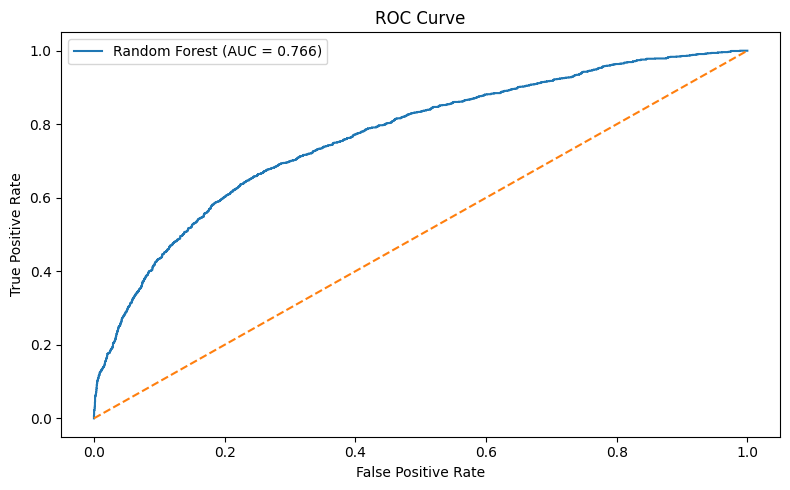

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/roc_curve_random_forest.png", dpi=300)
plt.show()

## Future Importance

In [26]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
7,delayed_month_count,0.244863
5,max_repayment_status,0.226357
6,avg_repayment_status,0.179348
9,avg_pay_amount,0.084459
10,avg_payment_bill_ratio,0.075865
8,avg_bill_amount,0.069826
4,limit_bal,0.066381
3,age,0.030043
1,education,0.011631
2,marriage,0.005619


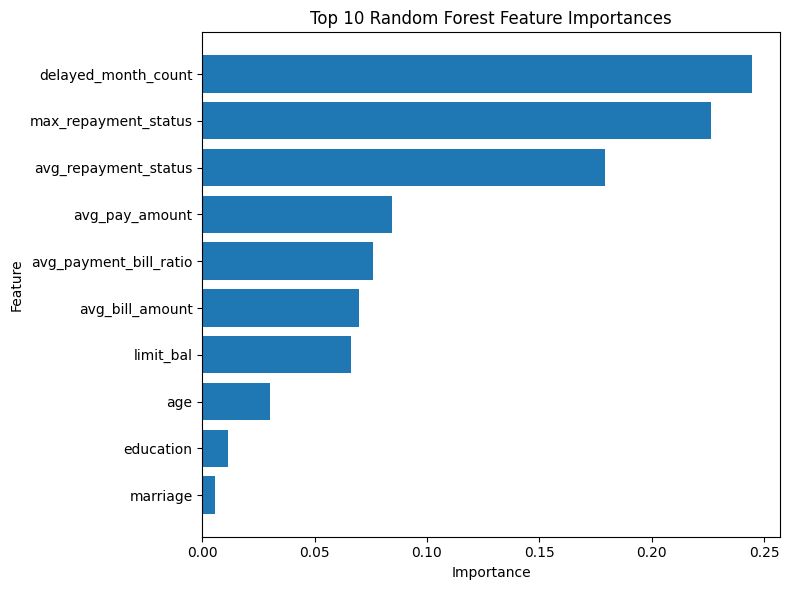

In [27]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("../figures/feature_importance_random_forest.png", dpi=300)
plt.show()

The feature importance results show that repayment-related variables are the strongest predictors in the model. The three most important features are `delayed_month_count` (0.245), `max_repayment_status` (0.226), and `avg_repayment_status` (0.179). This suggests that recent repayment behavior carries the most predictive information about whether a client will default next month.

Financial summary variables such as `avg_pay_amount`, `avg_payment_bill_ratio`, `avg_bill_amount`, and `limit_bal` also contribute to prediction, but their importance is noticeably lower than the repayment-history features. In contrast, demographic variables such as `education`, `marriage`, and `age` play a much smaller role in the model.

Overall, these results support the idea that recent behavioral signals are more informative than static background characteristics in predicting credit default risk.

## Discussion

The model results support the main idea of this project: recent repayment behavior is one of the strongest indicators of future default risk. Clients with more delayed months, worse repayment status, and weaker payment patterns are more likely to default in the following month. This is consistent with the financial logic of the problem, since recent payment difficulties often reflect growing financial stress.

These results also validate the relational data design used in the project. The original dataset stored repeated monthly information in a wide format, but restructuring it into relational tables made it easier to summarize repayment and financial history into client-level features. In this sense, the data design directly supported the modeling process.

At the same time, the model is not perfect. The recall is stronger than the precision, which means the model is better at identifying true default cases than at avoiding false alarms. For a credit risk setting, this may still be acceptable, since missing true high-risk clients can be more costly than flagging some lower-risk clients incorrectly.

## Conclusion

This project shows that demographic information, account information, repayment history, and monthly financial behavior can be used together to predict whether a client will default next month. Using the UCI Credit Card Default dataset, I first restructured the original wide table into relational tables, then used DuckDB and SQL to create a client-level modeling table, and finally trained a random forest classifier.

The final model achieved moderate predictive performance, with a ROC AUC of 0.766 and a recall of 0.625. The most important predictors were all related to repayment history, especially delayed months and repayment status. Overall, the project demonstrates how relational data design, SQL-based feature engineering, and machine learning can work together to support credit risk prediction.